2025-08-30 10:25:05.227490: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-30 10:25:19.633919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-30 10:25:31.552292: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-30 10:25:42.384236: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


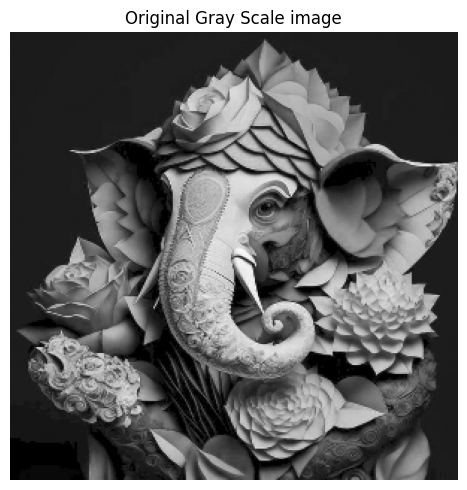

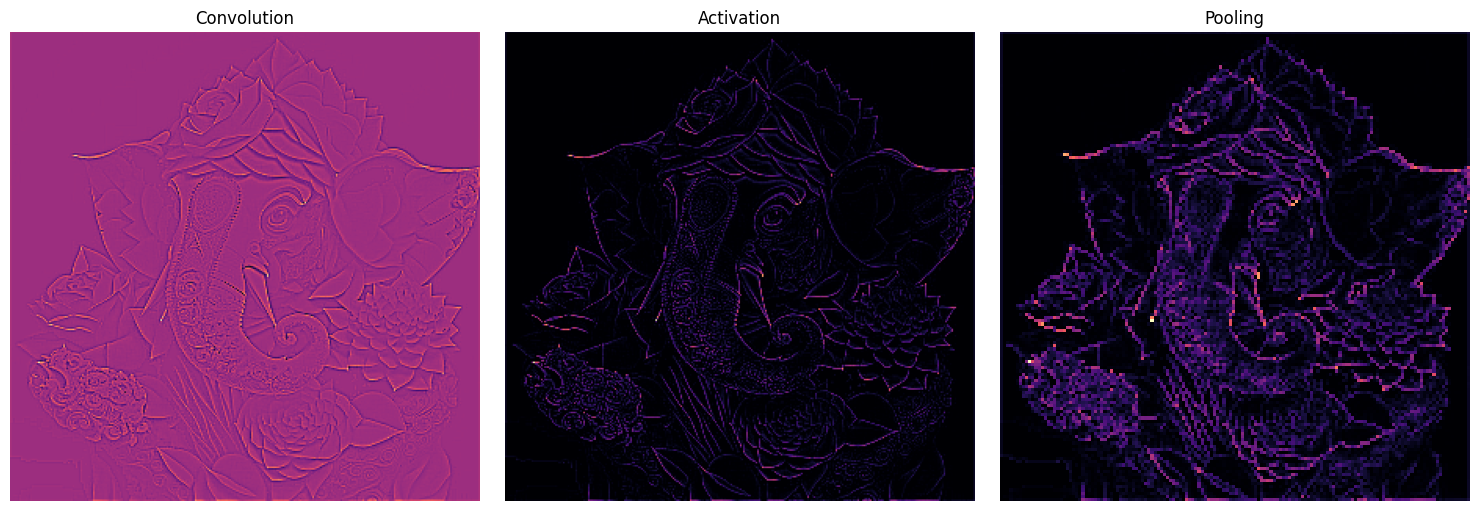

In [ ]:
# import the necessary libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# set the param
plt.rc('figure', autolayout=True)
plt.rc('image', cmap='magma')
# define the kernel
kernel = tf.constant([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1],])
# load the image
image = tf.io.read_file('image.png')
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[300, 300])
# plot the image
img = tf.squeeze(image).numpy()
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Gray Scale image')
plt.show();
# Reformat
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)
# convolution layer
conv_fn = tf.nn.conv2d
image_filter = conv_fn(
   input=image,
   filters=kernel,
   strides=1, # or (1, 1)
   padding='SAME',
)
plt.figure(figsize=(15, 5))
# Plot the convolved image
plt.subplot(1, 3, 1)
plt.imshow(
   tf.squeeze(image_filter)
)
plt.axis('off')
plt.title('Convolution')
# activation layer
relu_fn = tf.nn.relu
# Image detection
image_detect = relu_fn(image_filter)
plt.subplot(1, 3, 2)
plt.imshow(
   # Reformat for plotting
   tf.squeeze(image_detect)
)
plt.axis('off')
plt.title('Activation')
# Pooling layer
pool = tf.nn.pool
image_condense = pool(input=image_detect, window_shape=(2, 2),
pooling_type='MAX',strides=(2, 2),padding='SAME')
plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title('Pooling')
plt.show()